## 0. Import Libraries and Load the Real Kaggle Dataset

In [1]:

# Install KaggleHub in Google Colab
!pip -q install kagglehub

import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os

# Download the real Kaggle dataset
dataset_path = kagglehub.dataset_download(
    "adrianjuliusaluoch/daily-google-search-trends-us"
)

# Find CSV automatically
csv_files = glob.glob(
    os.path.join(dataset_path, "**", "*.csv"),
    recursive=True
)

print("Dataset downloaded to:")
print(dataset_path)
print("\nCSV file found:")
print(csv_files[0])

df = pd.read_csv(csv_files[0])

print("\nOriginal dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 records:")
display(df.head())


100%|██████████| 935k/935k [00:00<00:00, 79.0MB/s]

Extracting files...
Dataset downloaded to:
/root/.cache/kagglehub/datasets/adrianjuliusaluoch/daily-google-search-trends-us/versions/194

CSV file found:
/root/.cache/kagglehub/datasets/adrianjuliusaluoch/daily-google-search-trends-us/versions/194/trending_searches_in_us.csv

Original dataset shape: (31804, 8)

Column names:
['query', 'start_date', 'end_date', 'active', 'search_volume', 'increase_percentage', 'categories', 'trend_breakdown']

First 5 records:


,query,start_date,end_date,active,search_volume,increase_percentage,categories,trend_breakdown
0,shedeur sanders,2026-03-30 18:40:00+00:00,NaN,True,200,50,Sports,NaN
1,whoopi goldberg,2026-03-30 18:40:00+00:00,NaN,True,5000,50,Politics,"america first award, mike johnson"
2,mo williams,2026-03-30 18:00:00+00:00,NaN,True,5000,300,Sports,"mason williams basketball, mason williams"
3,sloane stephens,2026-03-30 17:50:00+00:00,NaN,True,1000,200,"Sports, Health",NaN
4,canceled tv shows 2026,2026-03-30 17:50:00+00:00,NaN,True,5000,200,Entertainment,renewed and cancelled tv shows 2026


## 1. Identifying Missing Values

In [2]:

# Boolean mask for missing entries
missing_mask = df.isnull()

print("Missing-value mask (first 5 rows):")
display(missing_mask.head())


Missing-value mask (first 5 rows):


,query,start_date,end_date,active,search_volume,increase_percentage,categories,trend_breakdown
0,False,False,True,False,False,False,False,True
1,False,False,True,False,False,False,False,False
2,False,False,True,False,False,False,False,False
3,False,False,True,False,False,False,False,True
4,False,False,True,False,False,False,False,False


## 2. Count Missing Values

Missing values per column:
query                      0
start_date                 0
end_date                1383
active                     0
search_volume              0
increase_percentage        0
categories                 0
trend_breakdown        19883
dtype: int64


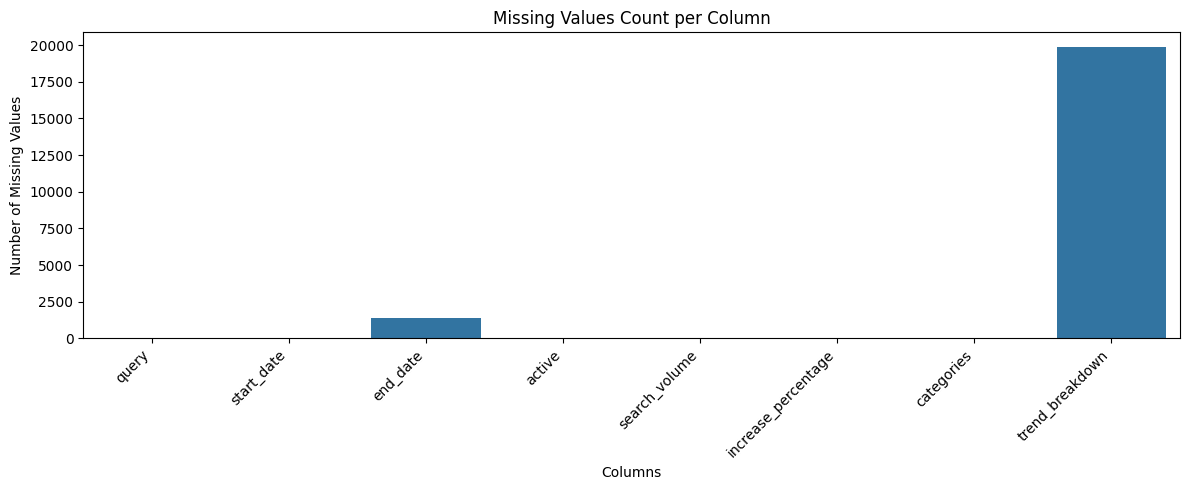

In [3]:

missing_counts = df.isnull().sum()

print("Missing values per column:")
print(missing_counts)

plt.figure(figsize=(12, 5))
sns.barplot(
    x=missing_counts.index,
    y=missing_counts.values
)
plt.title("Missing Values Count per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 3. Replace Missing Values

In [4]:

from sklearn.impute import SimpleImputer

# Identify numeric and categorical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

# Numerical columns -> mean
if num_cols:
    num_imputer = SimpleImputer(strategy="mean")
    df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical columns -> most frequent value
if cat_cols:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("\nMissing values after replacement:")
print(df.isnull().sum())


Numeric columns: ['search_volume', 'increase_percentage']
Categorical columns: ['query', 'start_date', 'end_date', 'categories', 'trend_breakdown']

Missing values after replacement:
query                  0
start_date             0
end_date               0
active                 0
search_volume          0
increase_percentage    0
categories             0
trend_breakdown        0
dtype: int64


## 4. Remove Duplicate Records

In [5]:

duplicate_count = df.duplicated().sum()

print("Total duplicate records found:", duplicate_count)

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Dataset shape after removing duplicates:", df.shape)


Total duplicate records found: 0
Dataset shape after removing duplicates: (31804, 8)


## 5. Detecting and Capping Outliers using IQR

In [6]:

numeric_features = df.select_dtypes(include=np.number).columns.tolist()

print("Numeric features:", numeric_features)

# Save a copy so we can compare before and after capping
df_before_outlier_capping = df.copy()

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    print(f"\nColumn: {col}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Outliers detected:", outliers)

    # IQR capping
    df[col] = np.where(
        df[col] < lower_bound,
        lower_bound,
        df[col]
    )

    df[col] = np.where(
        df[col] > upper_bound,
        upper_bound,
        df[col]
    )

print("\nOutlier detection and IQR capping completed.")


Numeric features: ['search_volume', 'increase_percentage']

Column: search_volume
Q1: 500.0
Q3: 10000.0
IQR: 9500.0
Lower bound: -13750.0
Upper bound: 24250.0
Outliers detected: 3188

Column: increase_percentage
Q1: 100.0
Q3: 300.0
IQR: 200.0
Lower bound: -200.0
Upper bound: 600.0
Outliers detected: 3099

Outlier detection and IQR capping completed.


### Outlier Visualization

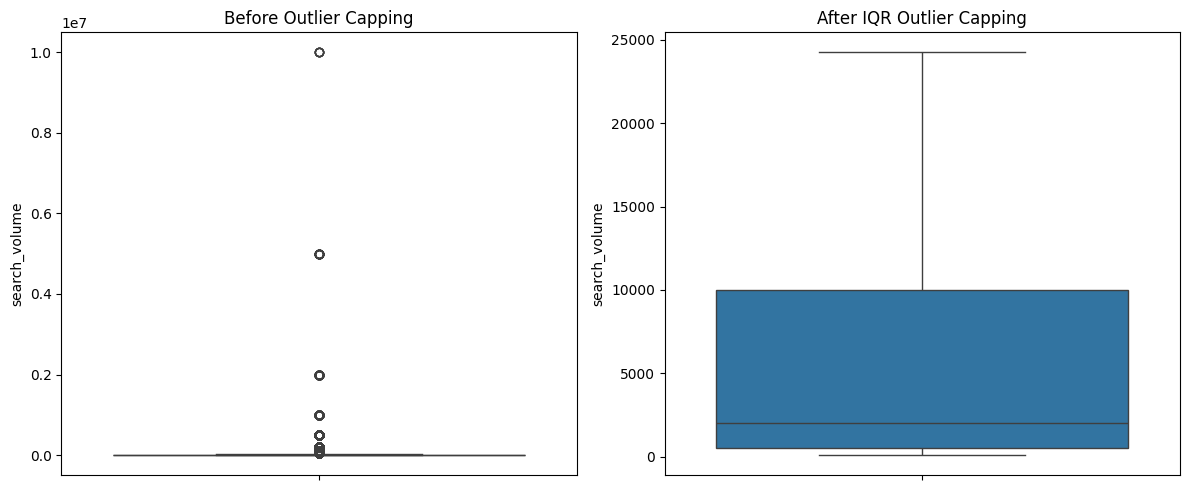

In [7]:

if numeric_features:
    # Plot the first numeric feature
    plot_col = numeric_features[0]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.boxplot(y=df_before_outlier_capping[plot_col])
    plt.title("Before Outlier Capping")
    plt.ylabel(plot_col)

    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[plot_col])
    plt.title("After IQR Outlier Capping")
    plt.ylabel(plot_col)

    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns available for box plot.")


## 6. Correcting Incorrect Data Types

In [8]:

print("Initial Data Types:")
print(df.dtypes)

# Convert columns containing date/time information
for col in df.columns:
    if "date" in col.lower() or "time" in col.lower():
        converted = pd.to_datetime(df[col], errors="coerce")

        # Only replace if conversion produced useful datetime values
        if converted.notna().sum() > 0:
            df[col] = converted

print("\nUpdated Data Types:")
print(df.dtypes)


Initial Data Types:
query                   object
start_date              object
end_date                object
active                    bool
search_volume          float64
increase_percentage    float64
categories              object
trend_breakdown         object
dtype: object

Updated Data Types:
query                               object
start_date             datetime64[ns, UTC]
end_date               datetime64[ns, UTC]
active                                bool
search_volume                      float64
increase_percentage                float64
categories                          object
trend_breakdown                     object
dtype: object


## 7. Resolving Inconsistent Formatting

In [9]:

string_cols = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Text columns being normalized:", string_cols)

for col in string_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

print("\nFormatted text columns sample:")
if string_cols:
    display(df[string_cols].head())
else:
    print("No text columns found.")


Text columns being normalized: ['query', 'categories', 'trend_breakdown']

Formatted text columns sample:


,query,categories,trend_breakdown
0,shedeur sanders,sports,dallas stars
1,whoopi goldberg,politics,"america first award, mike johnson"
2,mo williams,sports,"mason williams basketball, mason williams"
3,sloane stephens,"sports, health",dallas stars
4,canceled tv shows 2026,entertainment,renewed and cancelled tv shows 2026


## 8. Exploratory Visualization

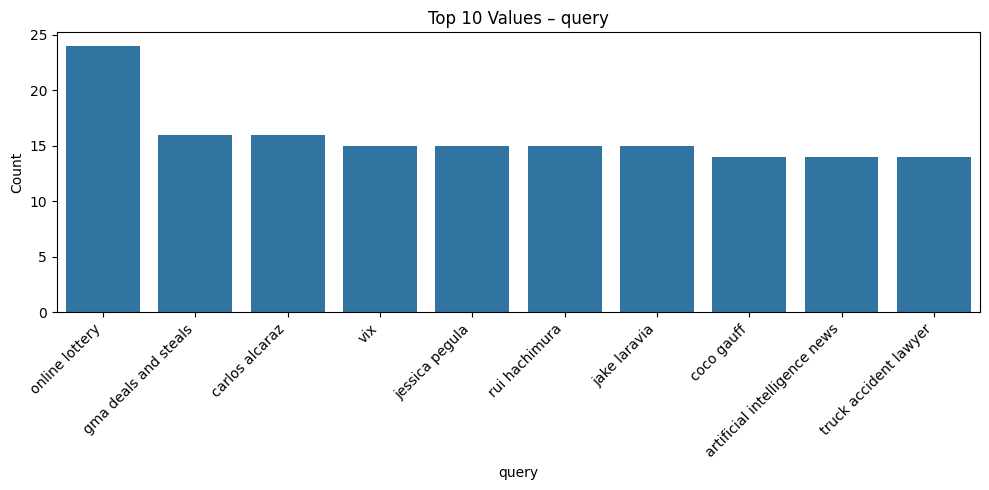

In [10]:

# Category/text frequency visualization
if string_cols:
    plot_col = string_cols[0]

    top_values = df[plot_col].value_counts().head(10)

    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=top_values.index,
        y=top_values.values
    )
    plt.title(f"Top 10 Values – {plot_col}")
    plt.xlabel(plot_col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No categorical/text column available for count plot.")


## Final Cleaned Dataset

In [11]:

print("Final cleaned dataset shape:", df.shape)
print("\nRemaining missing values:")
print(df.isnull().sum())

print("\nFinal data types:")
print(df.dtypes)

print("\nFirst 5 rows of cleaned dataset:")
display(df.head())


Final cleaned dataset shape: (31804, 8)

Remaining missing values:
query                  0
start_date             0
end_date               0
active                 0
search_volume          0
increase_percentage    0
categories             0
trend_breakdown        0
dtype: int64

Final data types:
query                               object
start_date             datetime64[ns, UTC]
end_date               datetime64[ns, UTC]
active                                bool
search_volume                      float64
increase_percentage                float64
categories                          object
trend_breakdown                     object
dtype: object

First 5 rows of cleaned dataset:


,query,start_date,end_date,active,search_volume,increase_percentage,categories,trend_breakdown
0,shedeur sanders,2026-03-30 18:40:00+00:00,2026-03-19 10:00:00+00:00,True,200.0,50.0,sports,dallas stars
1,whoopi goldberg,2026-03-30 18:40:00+00:00,2026-03-19 10:00:00+00:00,True,5000.0,50.0,politics,"america first award, mike johnson"
2,mo williams,2026-03-30 18:00:00+00:00,2026-03-19 10:00:00+00:00,True,5000.0,300.0,sports,"mason williams basketball, mason williams"
3,sloane stephens,2026-03-30 17:50:00+00:00,2026-03-19 10:00:00+00:00,True,1000.0,200.0,"sports, health",dallas stars
4,canceled tv shows 2026,2026-03-30 17:50:00+00:00,2026-03-19 10:00:00+00:00,True,5000.0,200.0,entertainment,renewed and cancelled tv shows 2026
